# Student Performance Prediction

## Data

The dataset contains information about students' academic performance and daily habits, including study hours, attendance, sleep duration, internet usage, assignments completed, and previous scores. Using these features, we aim to predict a student's **placement status** through machine learning model.

Before training the model, the dataset will be explored, cleaned, and preprocessed to ensure better performance and reliable predictions.

# Importing Libraries

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [110]:
df = pd.read_csv('student_dataset.csv')

## Dataset Overview

The dataset contains information about students and their academic activities. Each row represents a single student, while each column represents a specific feature related to their performance.

### Features

| Feature | Description |
|---------|-------------|
| **study_hours** | Number of hours a student studies per day. |
| **attendance** | Student's attendance percentage. |
| **sleep_hours** | Average hours of sleep per day. |
| **internet_usage** | Daily internet usage (in hours). |
| **assignments_completed** | Number of assignments completed by the student. |
| **previous_score** | Score obtained in the previous examination. |
| **exam_score** | Score obtained in the current examination (Target for Regression). |
| **placement_status** | Indicates whether the student was placed or not (Target for Classification). |

---


# Exploring Dataset

In [111]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [112]:
df.tail()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
9995,2,58,9,7,8,88,69.31,Not Placed
9996,7,98,6,9,4,87,100.00,Placed
9997,10,44,8,5,10,37,95.94,Placed
9998,10,75,7,5,8,52,88.61,Placed
9999,2,70,6,11,16,52,78.96,Placed


In [113]:
print("Shape:", df.shape)

Shape: (10000, 8)


In [114]:
print("\nStatistical Summary")
print(df.describe())


Statistical Summary
        study_hours   attendance   sleep_hours  internet_usage  \
count  10000.000000  10000.00000  10000.000000    10000.000000   
mean       5.989600     69.88460      6.498500        6.062600   
std        3.163589     17.61653      1.709354        3.138163   
min        1.000000     40.00000      4.000000        1.000000   
25%        3.000000     55.00000      5.000000        3.000000   
50%        6.000000     70.00000      6.500000        6.000000   
75%        9.000000     85.00000      8.000000        9.000000   
max       11.000000    100.00000      9.000000       11.000000   

       assignments_completed  previous_score    exam_score  
count           10000.000000     10000.00000  10000.000000  
mean                9.988400        64.91100     86.704207  
std                 6.034145        17.50302     15.058383  
min                 0.000000        35.00000     26.670000  
25%                 5.000000        50.00000     76.727500  
50%               

In [115]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64


In [116]:
print("\nData Types")
print(df.dtypes)


Data Types
study_hours                int64
attendance                 int64
sleep_hours                int64
internet_usage             int64
assignments_completed      int64
previous_score             int64
exam_score               float64
placement_status          object
dtype: object


In [117]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


In [118]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [119]:
df['placement_status'].value_counts()

placement_status
Placed        8356
Not Placed    1644
Name: count, dtype: int64

# Data Visualization

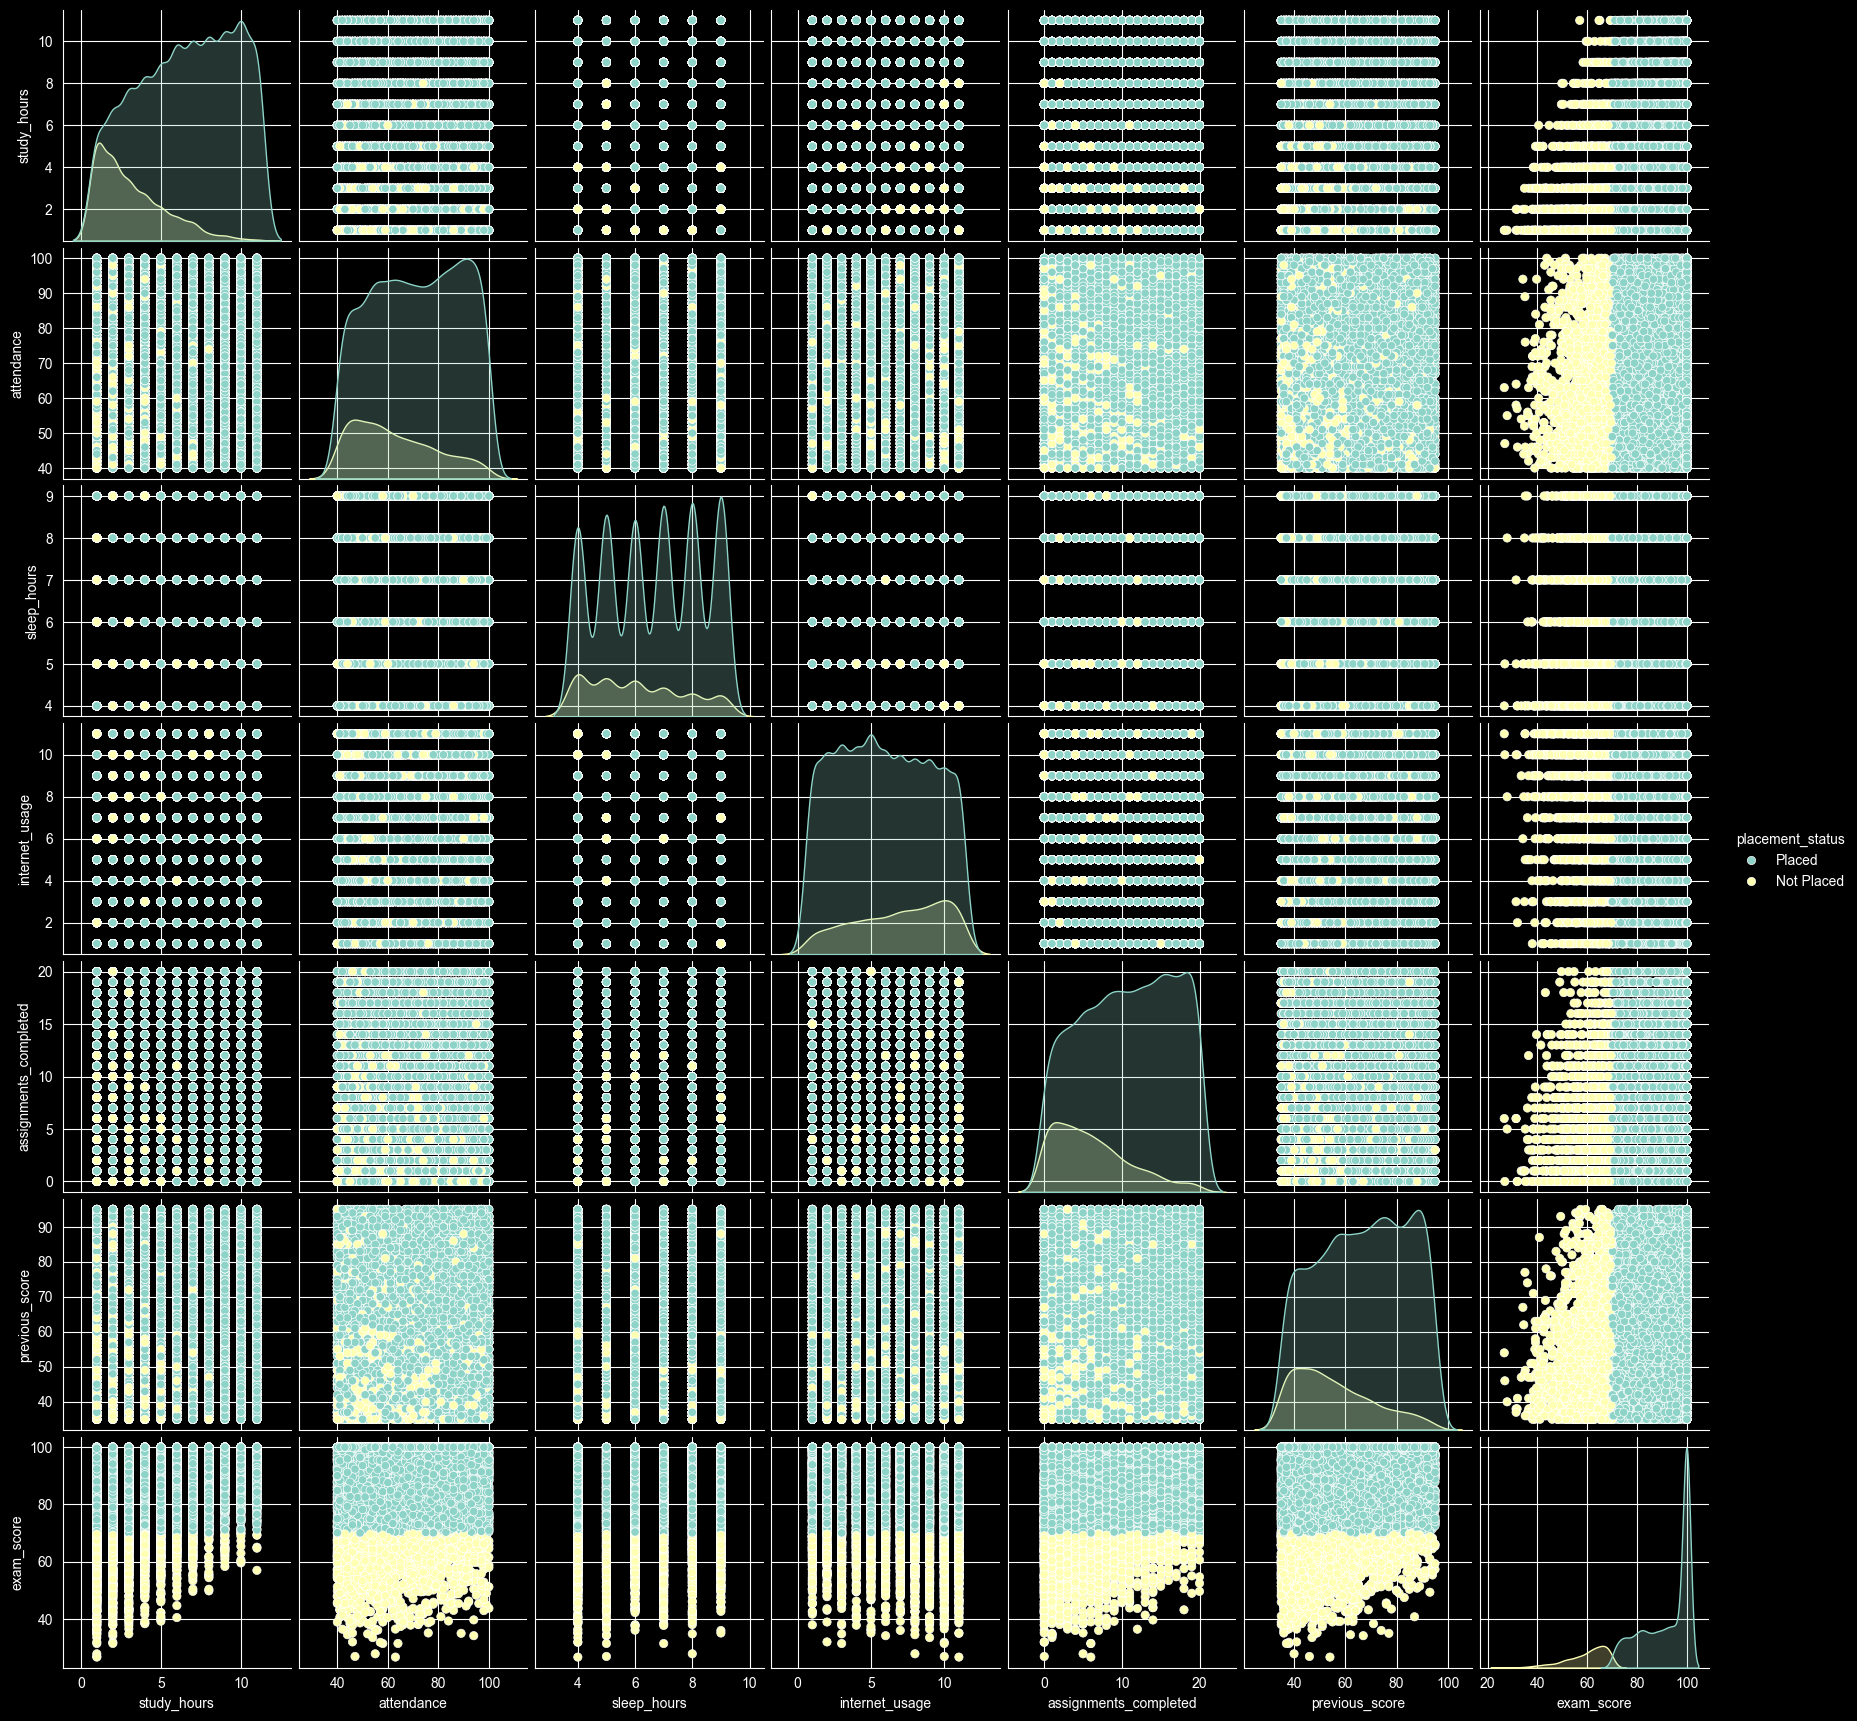

In [120]:
sns.pairplot(df, hue='placement_status')
plt.show()

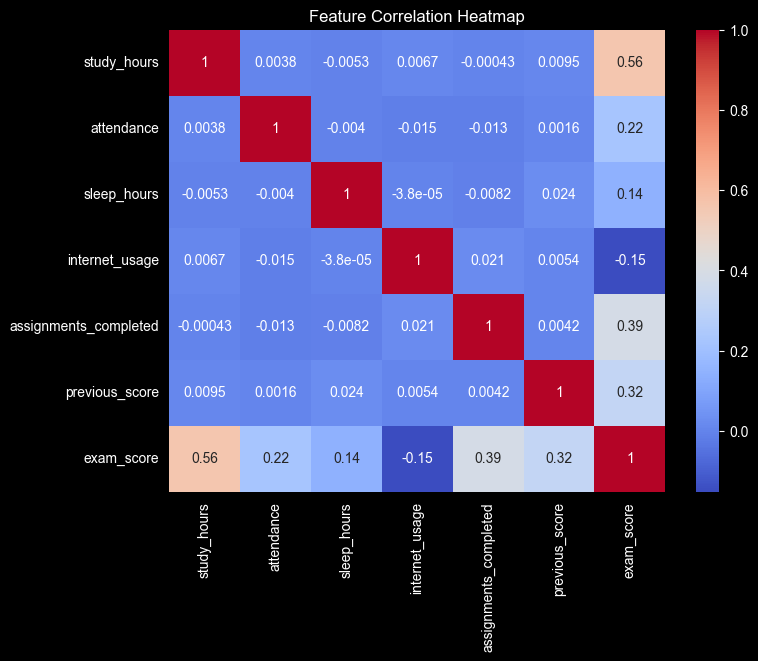

In [121]:
X = df.drop('placement_status', axis=1)

plt.figure(figsize=(8,6))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
)

plt.title("Feature Correlation Heatmap")
plt.show()

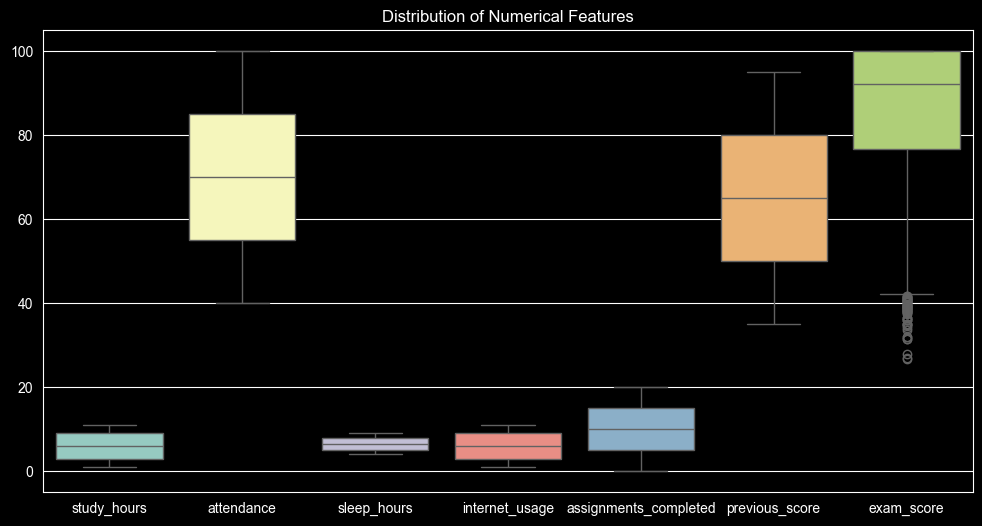

In [122]:
X = df.drop('placement_status', axis=1)
plt.figure(figsize=(12,6))

sns.boxplot(data=X)

plt.title("Distribution of Numerical Features")
plt.show()

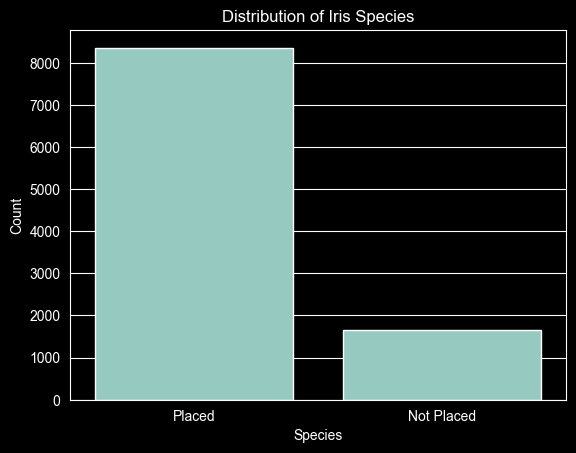

In [123]:
sns.countplot(data=df, x="placement_status")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

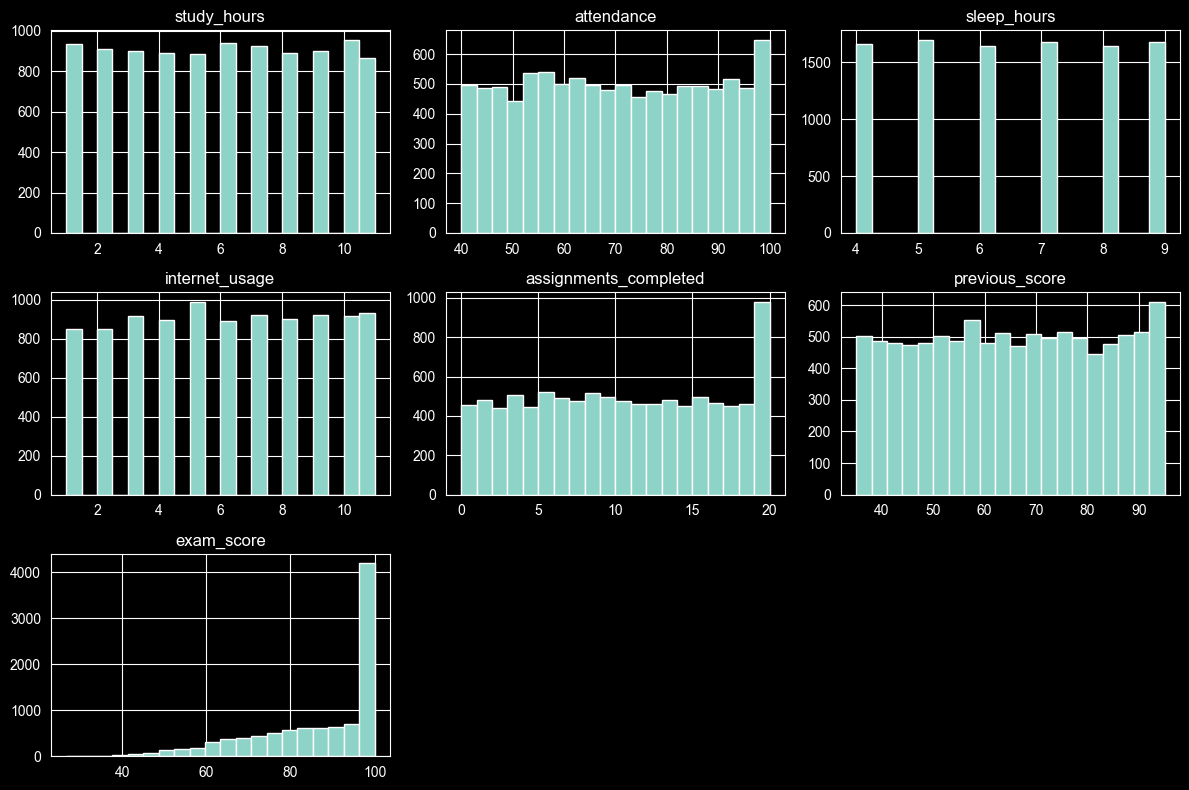

In [124]:
df.hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

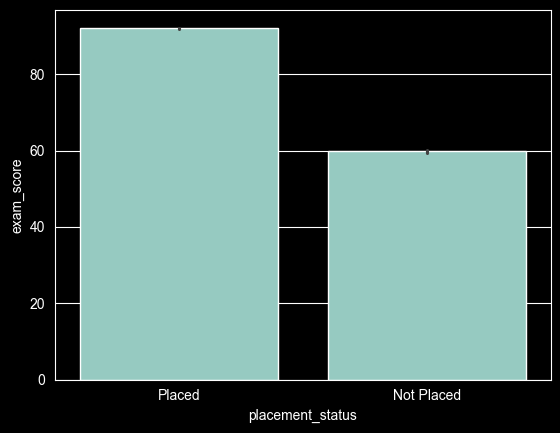

In [125]:
sns.barplot(
    x="placement_status",
    y="exam_score",
    data=df
)

# Model Training

## Importing Libraries for Model Training

In [126]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Encoding the Target Variable

Machine Learning models work with numerical data. Since the target column contains placement_status as text, we convert these labels into numerical values using **LabelEncoder**.

This allows the model to understand and classify the different placement_status.

In [127]:
encoder = LabelEncoder()

df['placement_status'] = encoder.fit_transform(df['placement_status'])

df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,1
1,4,69,5,3,8,56,100.00,1
2,11,60,7,6,10,45,100.00,1
3,8,99,9,8,4,55,90.17,1
4,5,52,8,6,8,40,78.82,1


## Splitting Features and Target

In [128]:
X = df.drop('placement_status', axis=1)
y = df['placement_status']

## Splitting the Dataset

To evaluate our model fairly, we divide the dataset into:

- Training Data (80%)
- Testing Data (20%)

The model learns from the training data and is evaluated using the testing data

In [129]:
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Training Samples: ", X_train.shape)
print("Testing Samples: ", X_test.shape)

Training Samples:  (8000, 7)
Testing Samples:  (2000, 7)


## Feature Scaling

The numerical features have different ranges. Feature scaling standardizes the data so that all features contribute equally during model training.

We use **StandardScaler**, which transforms the data to have a mean of 0 and a standard deviation of 1.

In [130]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Training the Model

In [131]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## Making Predictions

In [132]:
y_pred = model.predict(X_test)

print(y_pred)

[1 1 1 ... 1 1 0]


## Evaluating Model Performance

Evaluation tells us how well our model performs on unseen data.

We will calculate:
- Accuracy Score
- Confusion Matrix
- Classification Report

In [133]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9975


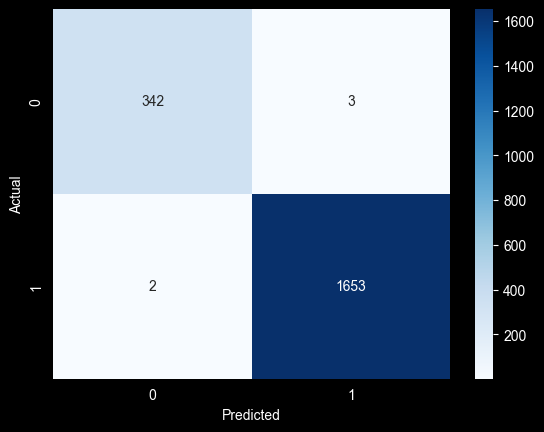

In [134]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [135]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       345
           1       1.00      1.00      1.00      1655

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



# Building Pipeline

## Import Required Libraries

In [136]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [137]:
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [138]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=100))
])

In [139]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [140]:
y_pred = pipeline.predict(X_test)

In [141]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9975


In [142]:
import joblib

joblib.dump(pipeline, './models/student_performance_model.pkl')
joblib.dump(X.columns.tolist(),'./models/features_names.pkl')

['./models/features_names.pkl']

In [143]:

new_student = pd.DataFrame({
    "study_hours": [6],
    "attendance": [90],
    "sleep_hours": [7],
    "internet_usage": [3],
    "assignments_completed": [9],
    "previous_score": [82],
    "exam_score": [85]
})

prediction = pipeline.predict(new_student)

print(prediction)

[1]
